In [17]:
# pip install yfinance pandas numpy

import pandas as pd
import numpy as np
import yfinance as yf

In [18]:
# -----------------------------
# 1) Choose your 30 S&P 500 stocks
# -----------------------------
tickers = [
    "MSFT", "AAPL", "NVDA", "ADBE",
    "UNH", "ABBV", "ABT",
    "JPM", "BRK-B", "V", "BLK",
    "HON", "CAT", "LMT",
    "AMZN", "HD", "MCD",
    "GOOGL", "META", "NFLX",
    "PG", "KO",
    "XOM", "CVX",
    "NEE", "SO",
    "LIN", "APD",
    "PLD", "AMT"
]

In [19]:
# -----------------------------
# 2) Download 5 years of adjusted-close prices
# -----------------------------
prices = yf.download(
    tickers,
    period="5y",
    interval="1d",
    auto_adjust=False,
    progress=False
)["Adj Close"]

# Clean up
prices = prices.dropna(how="all").sort_index()


In [20]:
# -----------------------------
# 3) Compute daily log returns
# -----------------------------
log_returns = np.log(prices / prices.shift(1)).dropna()

In [21]:
# -----------------------------
# 4) Download VIX from FRED
# -----------------------------
vix_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=VIXCLS"
vix = pd.read_csv(vix_url)

# Clean column names
vix.columns = [str(c).strip().replace("\ufeff", "") for c in vix.columns]

print("VIX columns:", vix.columns.tolist())  # optional debug line

# Handle possible column name differences
date_col = None
vix_col = None

for c in vix.columns:
    cl = c.lower()
    if cl in ["date", "observation_date"]:
        date_col = c
    if cl in ["vixcls", "value"]:
        vix_col = c

if date_col is None or vix_col is None:
    raise ValueError(f"Unexpected VIX columns: {vix.columns.tolist()}")

vix[date_col] = pd.to_datetime(vix[date_col])
vix[vix_col] = pd.to_numeric(vix[vix_col], errors="coerce")

vix = (
    vix.rename(columns={date_col: "Date", vix_col: "VIX"})
       .set_index("Date")
       .dropna()
)

VIX columns: ['observation_date', 'VIXCLS']


In [22]:
def label_vix_regime(v):
    if v < 15:
        return "low"
    elif v < 25:
        return "normal"
    else:
        return "crisis"

vix["regime"] = vix["VIX"].apply(label_vix_regime)
regime_map = {"low": 0, "normal": 1, "crisis": 2}
vix["regime_code"] = vix["regime"].map(regime_map)

In [23]:
# -----------------------------
# 6) Merge returns with VIX/regimes
# -----------------------------
data = log_returns.join(vix[["VIX", "regime", "regime_code"]], how="inner")

In [24]:
# -----------------------------
# 7) 80/20 temporal split (no shuffling)
# -----------------------------
split_idx = int(len(data) * 0.8)

train_data = data.iloc[:split_idx].copy()
test_data  = data.iloc[split_idx:].copy()

# Separate pieces if helpful
X_train_returns = train_data[tickers]
X_test_returns  = test_data[tickers]

vix_train = train_data["VIX"]
vix_test  = test_data["VIX"]

regime_train = train_data["regime_code"]
regime_test  = test_data["regime_code"]


In [25]:
# -----------------------------
# 8) Quick checks
# -----------------------------
print("Prices shape:", prices.shape)
print("Returns shape:", log_returns.shape)
print("Merged data shape:", data.shape)
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)
print("\nRegime counts (train):")
print(train_data["regime"].value_counts())
print("\nRegime counts (test):")
print(test_data["regime"].value_counts())

print("\nHead of merged dataset:")
print(data.head())

Prices shape: (1256, 30)
Returns shape: (1255, 30)
Merged data shape: (1254, 33)
Train shape: (1003, 33)
Test shape: (251, 33)

Regime counts (train):
regime
normal    619
low       236
crisis    148
Name: count, dtype: int64

Regime counts (test):
regime
normal    204
low        25
crisis     22
Name: count, dtype: int64

Head of merged dataset:
                AAPL      ABBV       ABT      ADBE       AMT      AMZN  \
Date                                                                     
2021-03-18 -0.034493 -0.012164  0.004157 -0.026580 -0.002962 -0.034963   
2021-03-19 -0.004490 -0.003379  0.017956  0.005269 -0.002925  0.015393   
2021-03-22  0.027942  0.023697  0.010094  0.024411  0.017736  0.011611   
2021-03-23 -0.006912 -0.010060 -0.008100  0.017072  0.017644  0.008524   
2021-03-24 -0.020196 -0.017124 -0.020713 -0.019064 -0.012477 -0.016204   

                 APD       BLK     BRK-B       CAT  ...      NVDA        PG  \
Date                                                .

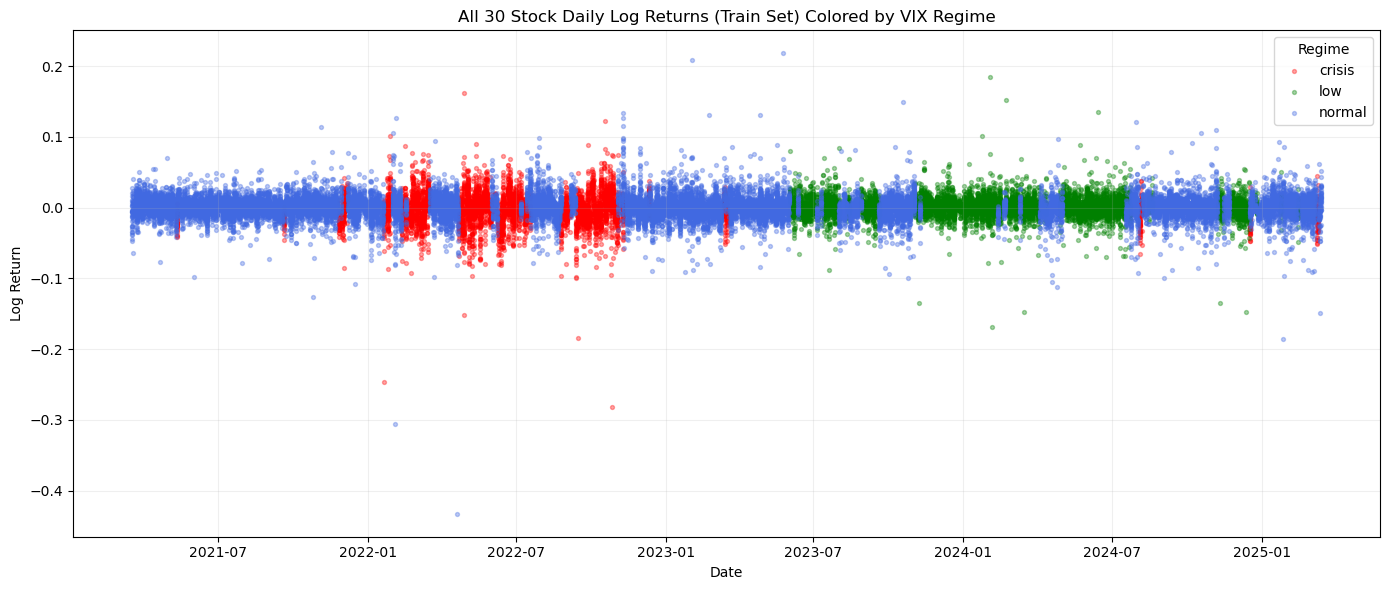

In [26]:
import matplotlib.pyplot as plt

# Long format: one row per (Date, Ticker, return)
returns_long = (
    X_train_returns.stack()
    .rename("return")
    .reset_index()
    .rename(columns={"level_1": "Ticker"})
)

# Add regime by date
returns_long["regime"] = returns_long["Date"].map(train_data["regime"])

# Color map for regimes
regime_colors = {"low": "green", "normal": "royalblue", "crisis": "red"}

plt.figure(figsize=(14, 6))
for r, grp in returns_long.groupby("regime"):
    plt.scatter(grp["Date"], grp["return"], s=8, alpha=0.35, c=regime_colors.get(r, "gray"), label=r)

plt.title("All 30 Stock Daily Log Returns (Train Set) Colored by VIX Regime")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend(title="Regime")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


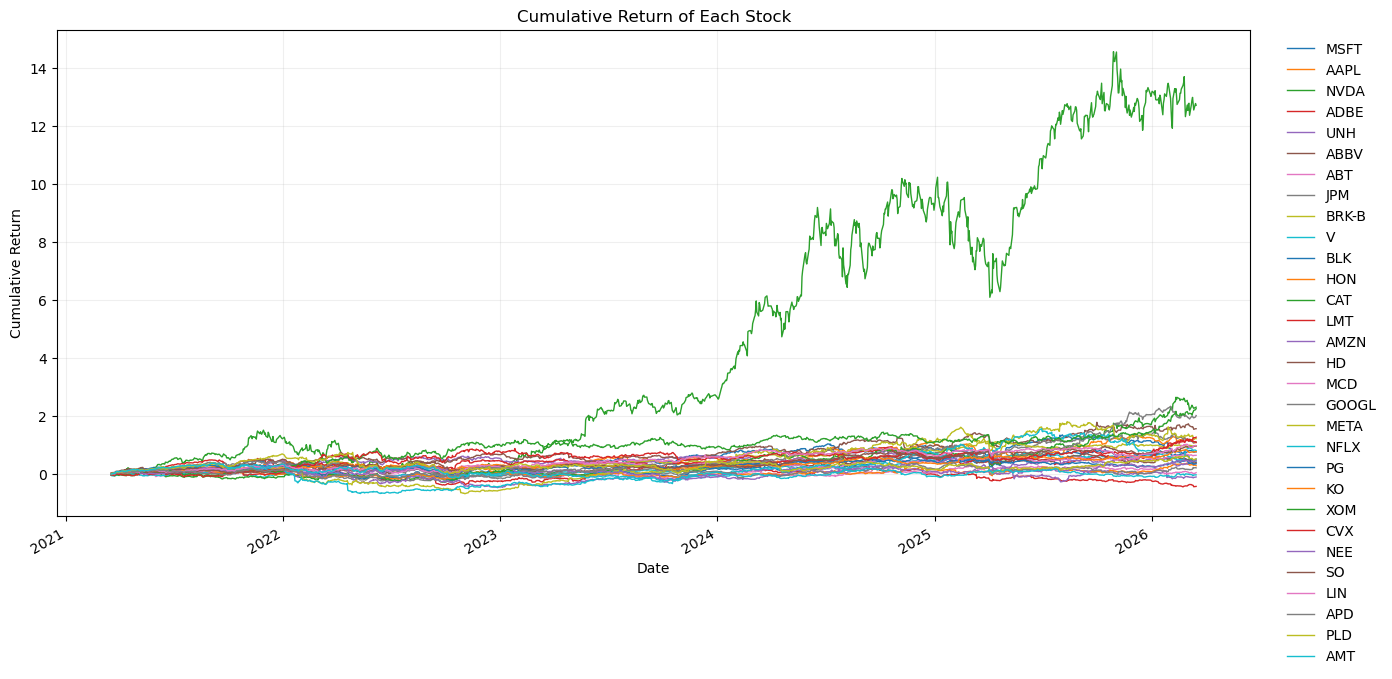

In [27]:
# Cumulative return from daily log returns: exp(cumsum(log_returns)) - 1
cum_returns = np.exp(log_returns[tickers].cumsum()) - 1

plt.figure(figsize=(14, 7))
cum_returns.plot(ax=plt.gca(), linewidth=1)
plt.title("Cumulative Return of Each Stock")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(alpha=0.2)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), ncol=1, frameon=False)
plt.tight_layout()
plt.show()

In [28]:
returns = data[tickers].copy()

print("Full data shape:", data.shape)
print("Returns shape:", returns.shape)
print("Date range:", data.index.min(), "to", data.index.max())
print("\nMissing values per column:")
print(data.isna().sum().sort_values(ascending=False).head(15))

split_idx = int(len(data) * 0.8)
print("\nTrain date range:", data.index[:split_idx].min(), "to", data.index[:split_idx].max())
print("Test date range:", data.index[split_idx:].min(), "to", data.index[split_idx:].max())

Full data shape: (1254, 33)
Returns shape: (1254, 30)
Date range: 2021-03-18 00:00:00 to 2026-03-16 00:00:00

Missing values per column:
AAPL      0
LMT       0
regime    0
VIX       0
XOM       0
V         0
UNH       0
SO        0
PLD       0
PG        0
NVDA      0
NFLX      0
NEE       0
MSFT      0
META      0
dtype: int64

Train date range: 2021-03-18 00:00:00 to 2025-03-14 00:00:00
Test date range: 2025-03-17 00:00:00 to 2026-03-16 00:00:00


Regime counts:
regime
crisis    170
low       261
normal    823
Name: count, dtype: int64

Regime percentages:
regime
crisis    13.56
low       20.81
normal    65.63
Name: proportion, dtype: float64


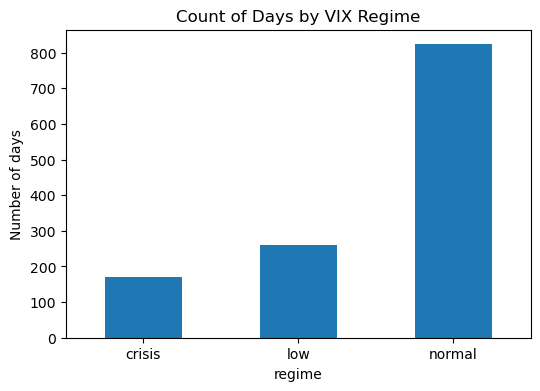

In [29]:
regime_counts = data["regime"].value_counts().sort_index()
regime_pct = data["regime"].value_counts(normalize=True).sort_index() * 100

print("Regime counts:")
print(regime_counts)
print("\nRegime percentages:")
print(regime_pct.round(2))

regime_counts.plot(kind="bar", figsize=(6,4), title="Count of Days by VIX Regime")
plt.ylabel("Number of days")
plt.xticks(rotation=0)
plt.show()

In [30]:
summary = pd.DataFrame({
    "mean": returns.mean(),
    "std": returns.std(),
    "skew": returns.skew(),
    "kurtosis": returns.kurtosis(),
    "min": returns.min(),
    "q01": returns.quantile(0.01),
    "q05": returns.quantile(0.05),
    "median": returns.median(),
    "q95": returns.quantile(0.95),
    "q99": returns.quantile(0.99),
    "max": returns.max()
}).sort_values("std", ascending=False)

print(summary.round(4))

         mean     std    skew  kurtosis     min     q01     q05  median  \
NVDA   0.0021  0.0323  0.2487    3.8199 -0.1859 -0.0774 -0.0487  0.0029   
NFLX   0.0005  0.0280 -3.1350   51.8719 -0.4326 -0.0698 -0.0357  0.0008   
META   0.0006  0.0277 -1.1693   26.3370 -0.3064 -0.0665 -0.0394  0.0007   
ADBE  -0.0005  0.0227 -1.2624    9.7054 -0.1838 -0.0750 -0.0334  0.0001   
AMZN   0.0002  0.0222 -0.1068    5.0969 -0.1514 -0.0577 -0.0334  0.0004   
UNH   -0.0001  0.0203 -3.3653   38.9316 -0.2533 -0.0591 -0.0257  0.0007   
GOOGL  0.0009  0.0193 -0.0625    3.2459 -0.0999 -0.0484 -0.0290  0.0014   
CAT    0.0009  0.0186  0.2051    3.5451 -0.0903 -0.0472 -0.0281  0.0011   
AAPL   0.0006  0.0173  0.2426    5.8958 -0.0970 -0.0455 -0.0276  0.0011   
PLD    0.0003  0.0170 -0.2196    3.5916 -0.1006 -0.0461 -0.0269  0.0009   
NEE    0.0003  0.0168 -0.6023    4.1781 -0.0940 -0.0493 -0.0254  0.0010   
XOM    0.0009  0.0167 -0.2765    1.4118 -0.0821 -0.0435 -0.0270  0.0013   
BLK    0.0003  0.0166  0.

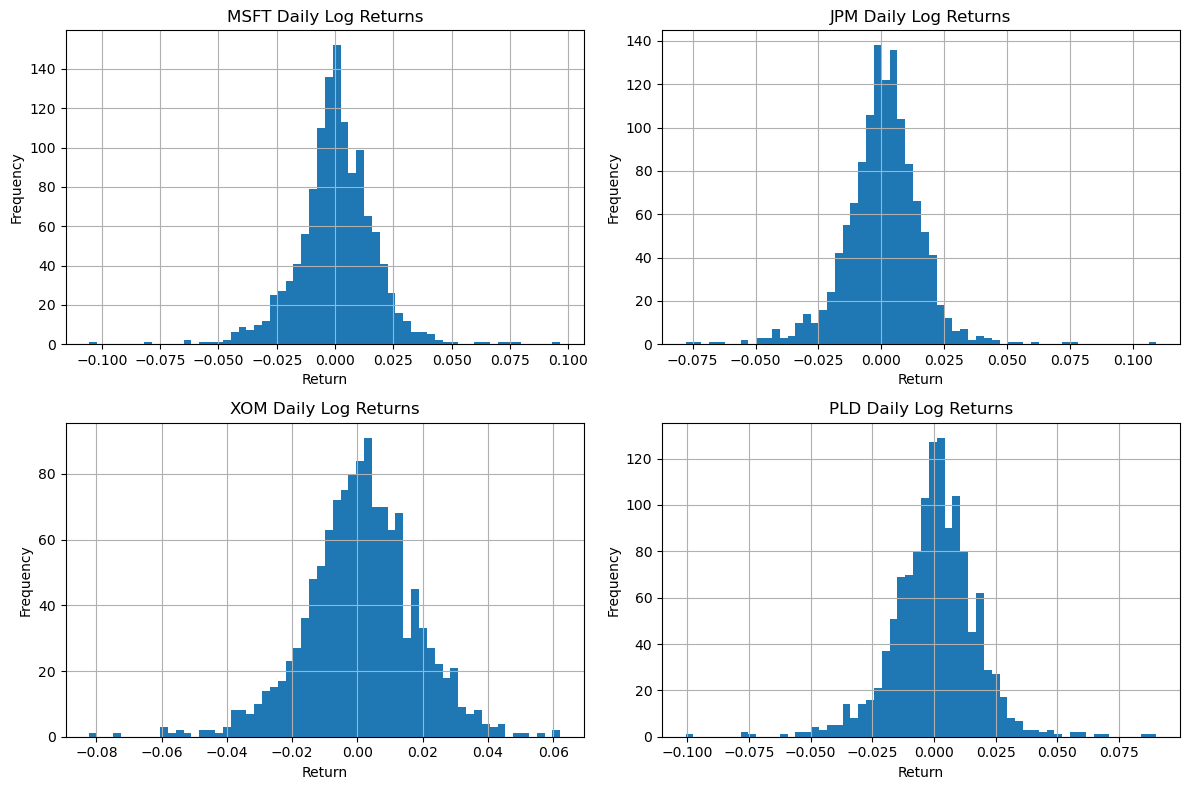

In [31]:
sample_stocks = ["MSFT", "JPM", "XOM", "PLD"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, stock in zip(axes, sample_stocks):
    returns[stock].hist(bins=60, ax=ax)
    ax.set_title(f"{stock} Daily Log Returns")
    ax.set_xlabel("Return")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [32]:
regime_stats = []

for r in ["low", "normal", "crisis"]:
    subset = data.loc[data["regime"] == r, tickers]
    regime_stats.append({
        "regime": r,
        "avg_abs_return": subset.abs().stack().mean(),
        "avg_std_across_assets": subset.std().mean(),
        "worst_1pct_quantile_avg": subset.quantile(0.01).mean(),
        "best_99pct_quantile_avg": subset.quantile(0.99).mean()
    })

regime_stats = pd.DataFrame(regime_stats).set_index("regime")
print(regime_stats.round(4))

        avg_abs_return  avg_std_across_assets  worst_1pct_quantile_avg  \
regime                                                                   
low             0.0096                 0.0133                  -0.0314   
normal          0.0114                 0.0159                  -0.0402   
crisis          0.0185                 0.0243                  -0.0595   

        best_99pct_quantile_avg  
regime                           
low                      0.0338  
normal                   0.0403  
crisis                   0.0524  


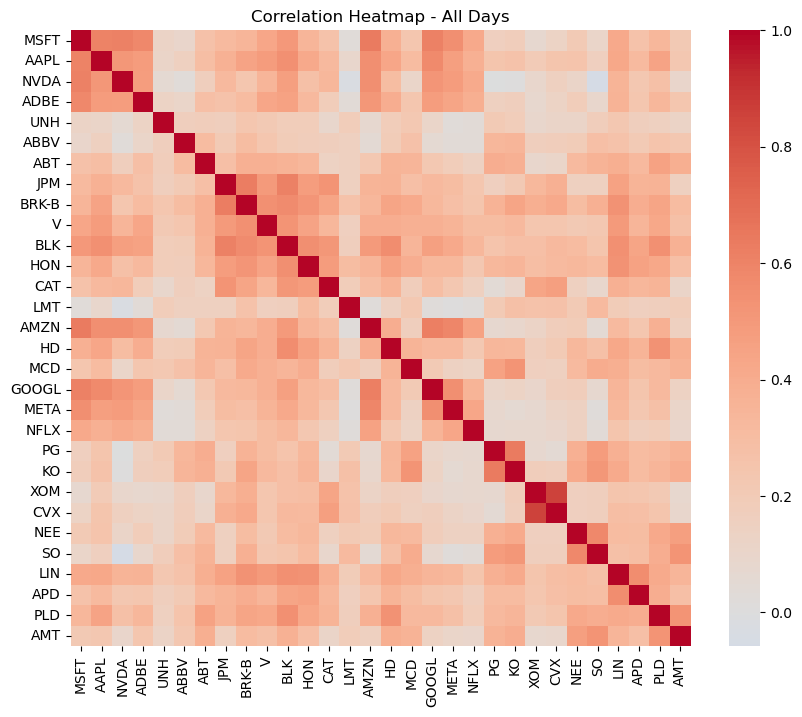

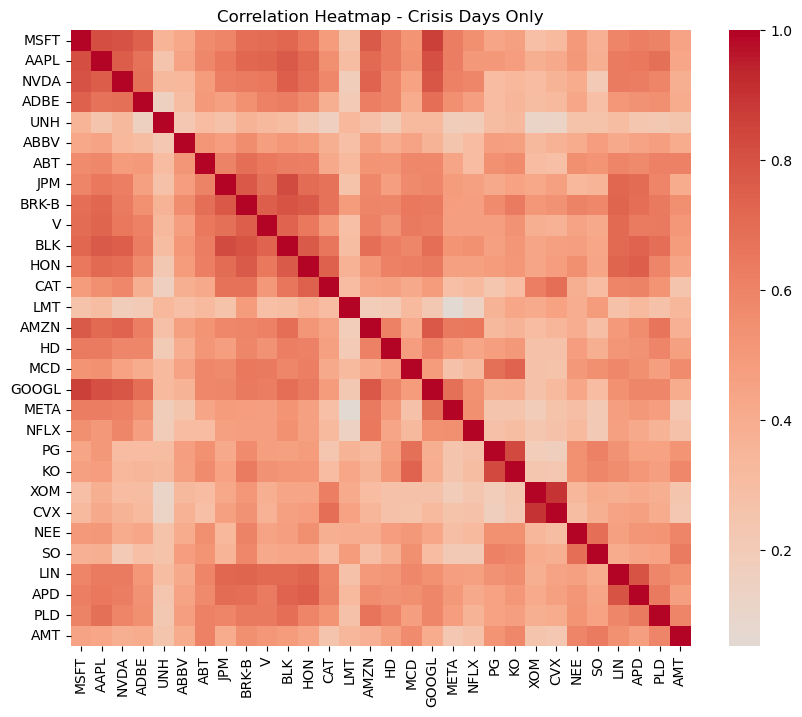

In [33]:
import seaborn as sns

corr_all = data[tickers].corr()
corr_crisis = data.loc[data["regime"] == "crisis", tickers].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_all, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - All Days")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_crisis, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Crisis Days Only")
plt.show()

            EW_portfolio_return    VIX  regime
Date                                          
2025-04-04            -0.057881  45.31  crisis
2022-09-13            -0.045157  27.27  crisis
2022-06-13            -0.038826  34.02  crisis
2022-04-29            -0.036593  33.40  crisis
2022-05-18            -0.036295  30.96  crisis
2022-05-05            -0.035553  31.20  crisis
2022-08-26            -0.033758  25.56  crisis
2022-05-09            -0.033029  34.75  crisis
2022-06-10            -0.032283  27.75  crisis
2025-04-03            -0.032132  30.02  crisis
2022-06-16            -0.028873  32.95  crisis
2022-02-03            -0.028721  24.35  normal
2024-08-05            -0.028151  38.57  crisis
2022-10-07            -0.025755  31.36  crisis
2022-12-15            -0.025554  22.83  normal


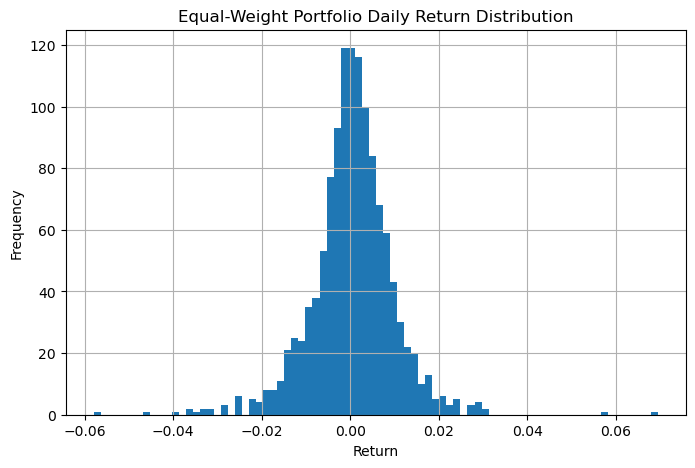

In [34]:
ew_ret = returns.mean(axis=1)
tail_table = pd.DataFrame({
    "EW_portfolio_return": ew_ret,
    "VIX": data["VIX"],
    "regime": data["regime"]
}).sort_values("EW_portfolio_return")

print(tail_table.head(15))

tail_table["EW_portfolio_return"].hist(bins=80, figsize=(8,5))
plt.title("Equal-Weight Portfolio Daily Return Distribution")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()